# Metamorphic Testing MNIST - Interactive Playground

Explore metamorphic relations (MRs) dynamically:
- Load images interactively
- Apply transformations
- Compare predictions
- Adjust thresholds
- Detect bugs in real-time

## 0. Fix Working Directory

In [3]:
# Fix working directory (notebook might be run from notebooks/ subdirectory)
import os
from pathlib import Path

current_dir = Path.cwd()
print(f"Current directory: {current_dir}")

# If we're in notebooks/, go up to project root
if current_dir.name == "notebooks":
    project_root = current_dir.parent
    os.chdir(project_root)
    print(f"Changed to project root: {os.getcwd()}")
else:
    print(f"Already in project root: {current_dir}")

# Verify config file exists
config_exists = Path("configs/mnist.yaml").exists()
print(f"✓ Config file found: {config_exists}")

Current directory: c:\Projets\Tests métamorphiques
Already in project root: c:\Projets\Tests métamorphiques
✓ Config file found: True


## 1. Setup & Imports

In [4]:
# Fix working directory (notebook might be run from different location)
import os
from pathlib import Path

# Get the notebook directory
notebook_dir = Path.cwd()
print(f"Current directory: {notebook_dir}")

# Change to project root (parent of notebooks/ directory)
if notebook_dir.name == "notebooks":
    project_root = notebook_dir.parent
else:
    project_root = notebook_dir

os.chdir(project_root)
print(f"Changed to project root: {os.getcwd()}")
print(f"Config file exists: {(project_root / 'configs' / 'mnist.yaml').exists()}")

Current directory: c:\Projets\Tests métamorphiques
Changed to project root: c:\Projets\Tests métamorphiques
Config file exists: True


In [5]:
import sys
sys.path.insert(0, '.')

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml

from models.mnist_simple import TrainConfig, load_or_train_model
from src.dataset import MnistDataConfig, build_dataloaders
from src.inference import predict_logits, predict_top1
from src.transforms import (
    adjust_brightness,
    gaussian_blur,
    horizontal_flip,
    rotate_tensor,
)

print("✓ All imports successful")

✓ All imports successful


## 2. Load Model & Dataset

In [6]:
# Load configuration
config_path = Path("configs/mnist.yaml")
config = yaml.safe_load(config_path.read_text(encoding="utf-8"))

# Setup device
device = torch.device("cpu")
print(f"Device: {device}")

# Load data
data_cfg = MnistDataConfig(seed=int(config["seed"]))
train_loader, eval_loader = build_dataloaders(data_cfg)

# Load model
train_cfg = TrainConfig(
    learning_rate=float(config["learning_rate"]),
    train_epochs=int(config["train_epochs"]),
    artifact_path=str(config["artifact_path"]),
)
model = load_or_train_model(train_loader, train_cfg, device)

# Load eval images
images, labels = next(iter(eval_loader))

print(f"✓ Model loaded")
print(f"✓ Dataset: {images.shape[0]} eval images, shape {images.shape[1:]}")
print(f"✓ Config seed: {config['seed']}")

Device: cpu
✓ Model loaded
✓ Dataset: 64 eval images, shape torch.Size([1, 28, 28])
✓ Config seed: 42


## 3. Interactive MR Explorer

Select an image index and explore different transformations.

In [8]:
# Choose image index (0-127, default 0)
image_idx = 10  # Change this to explore different images

source_image = images[image_idx:image_idx+1]
source_logits = predict_logits(model, source_image, device)[0]
source_pred = torch.argmax(source_logits).item()

print(f"Selected image {image_idx}")
print(f"Source prediction: {source_pred}")
print(f"Source confidence: {source_logits.max().item():.3f}")

Selected image 10
Source prediction: 6
Source confidence: 0.416


## 4. MR1: Identity (Clone)

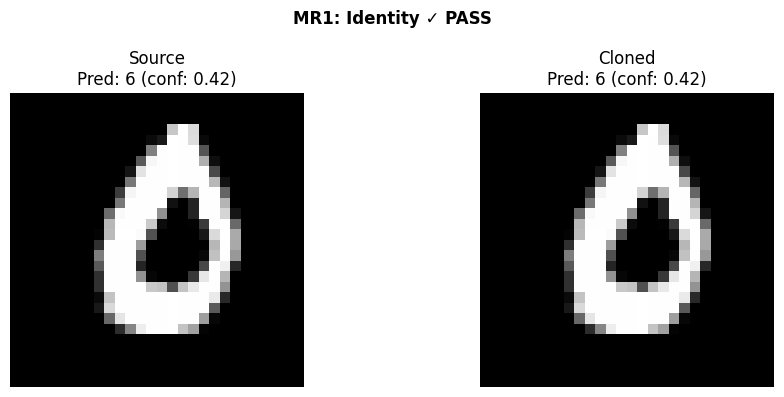

Logit diff: 0.00e+00 (threshold: 1.00e-06) → PASS


In [9]:
# MR1: Clone should be identical
follow_up = source_image.clone()
follow_up_logits = predict_logits(model, follow_up, device)[0]
follow_up_pred = torch.argmax(follow_up_logits).item()

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(source_image[0].squeeze().numpy(), cmap='gray')
axes[0].set_title(f'Source\nPred: {source_pred} (conf: {source_logits.max():.2f})')
axes[0].axis('off')

axes[1].imshow(follow_up[0].squeeze().numpy(), cmap='gray')
axes[1].set_title(f'Cloned\nPred: {follow_up_pred} (conf: {follow_up_logits.max():.2f})')
axes[1].axis('off')

verdict = "✓ PASS" if source_pred == follow_up_pred else "✗ FAIL"
fig.suptitle(f'MR1: Identity {verdict}', fontweight='bold')
plt.tight_layout()
plt.show()

# Check threshold
logit_diff = torch.max(torch.abs(source_logits - follow_up_logits)).item()
threshold = float(config["thresholds"]["identity_max_logit_diff"])
print(f"Logit diff: {logit_diff:.2e} (threshold: {threshold:.2e}) → {'PASS' if logit_diff <= threshold else 'FAIL'}")

## 5. MR2: Double Flip

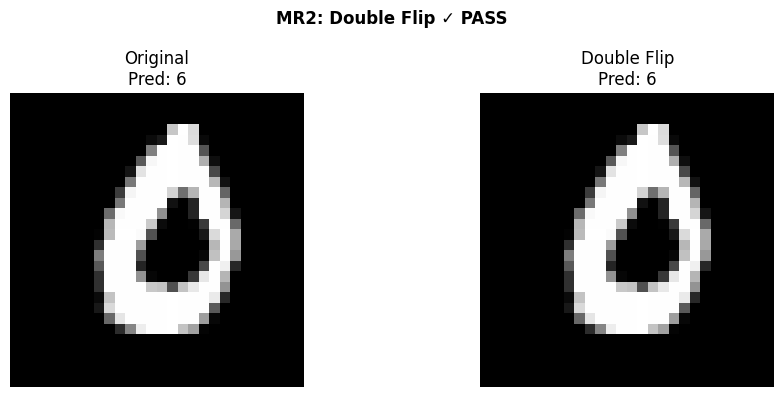

Logit diff: 0.000 (threshold: 0.000) → PASS


In [10]:
# MR2: Double flip should restore
follow_up = horizontal_flip(horizontal_flip(source_image))
follow_up_logits = predict_logits(model, follow_up, device)[0]
follow_up_pred = torch.argmax(follow_up_logits).item()

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(source_image[0].squeeze().numpy(), cmap='gray')
axes[0].set_title(f'Original\nPred: {source_pred}')
axes[0].axis('off')

axes[1].imshow(follow_up[0].squeeze().numpy(), cmap='gray')
axes[1].set_title(f'Double Flip\nPred: {follow_up_pred}')
axes[1].axis('off')

verdict = "✓ PASS" if source_pred == follow_up_pred else "✗ FAIL"
fig.suptitle(f'MR2: Double Flip {verdict}', fontweight='bold')
plt.tight_layout()
plt.show()

logit_diff = torch.max(torch.abs(source_logits - follow_up_logits)).item()
threshold = float(config["thresholds"]["double_flip_max_logit_diff"])
print(f"Logit diff: {logit_diff:.3f} (threshold: {threshold:.3f}) → {'PASS' if logit_diff <= threshold else 'FAIL'}")

## 6. MR3: Rotate + Inverse Rotate

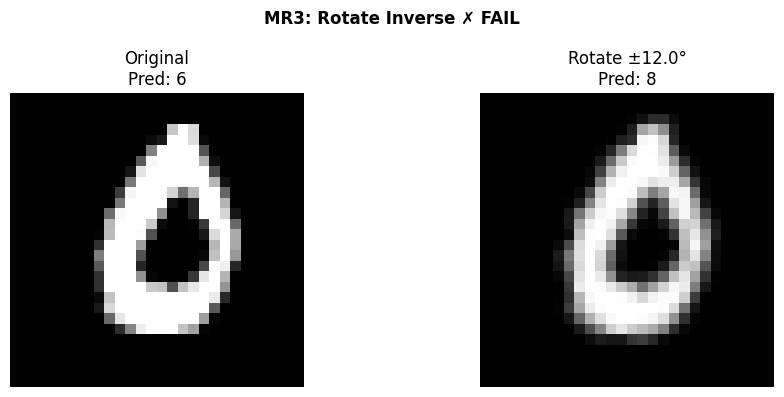

Logit diff: 0.037 (threshold: 0.250) → PASS


In [11]:
# MR3: Small rotation then inverse
rotate_angle = 12.0  # degrees (change this to explore)
follow_up = rotate_tensor(rotate_tensor(source_image, rotate_angle), -rotate_angle)
follow_up_logits = predict_logits(model, follow_up, device)[0]
follow_up_pred = torch.argmax(follow_up_logits).item()

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(source_image[0].squeeze().numpy(), cmap='gray')
axes[0].set_title(f'Original\nPred: {source_pred}')
axes[0].axis('off')

axes[1].imshow(follow_up[0].squeeze().numpy(), cmap='gray')
axes[1].set_title(f'Rotate ±{rotate_angle}°\nPred: {follow_up_pred}')
axes[1].axis('off')

verdict = "✓ PASS" if source_pred == follow_up_pred else "✗ FAIL"
fig.suptitle(f'MR3: Rotate Inverse {verdict}', fontweight='bold')
plt.tight_layout()
plt.show()

logit_diff = torch.max(torch.abs(source_logits - follow_up_logits)).item()
threshold = float(config["thresholds"]["rotate_inverse_max_logit_diff"])
print(f"Logit diff: {logit_diff:.3f} (threshold: {threshold:.3f}) → {'PASS' if logit_diff <= threshold else 'FAIL'}")

## 7. MR4: Brightness Stability

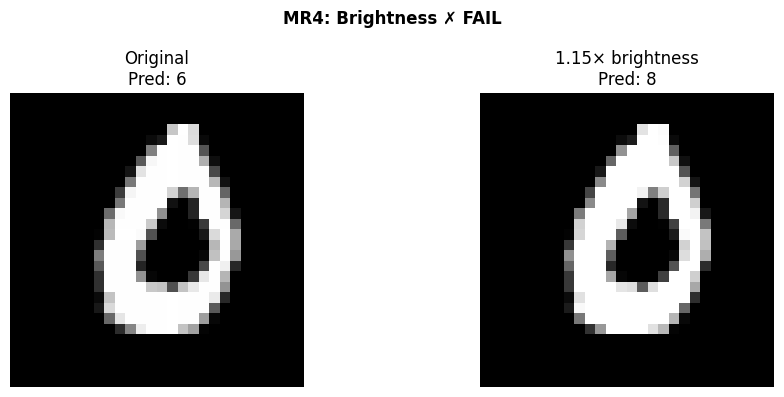

Top-1 match: False (threshold: 0.85) → FAIL


In [12]:
# MR4: Brightness change
brightness_factor = 1.15  # 1.0 = no change, <1 = darker, >1 = brighter
follow_up = adjust_brightness(source_image, brightness_factor)
follow_up_logits = predict_logits(model, follow_up, device)[0]
follow_up_pred = torch.argmax(follow_up_logits).item()

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(source_image[0].squeeze().numpy(), cmap='gray')
axes[0].set_title(f'Original\nPred: {source_pred}')
axes[0].axis('off')

axes[1].imshow(follow_up[0].squeeze().numpy(), cmap='gray')
axes[1].set_title(f'{brightness_factor}× brightness\nPred: {follow_up_pred}')
axes[1].axis('off')

verdict = "✓ PASS" if source_pred == follow_up_pred else "✗ FAIL"
fig.suptitle(f'MR4: Brightness {verdict}', fontweight='bold')
plt.tight_layout()
plt.show()

match_rate = (source_pred == follow_up_pred)
threshold = float(config["thresholds"]["brightness_top1_match_rate"])
print(f"Top-1 match: {match_rate} (threshold: {threshold}) → {'PASS' if match_rate else 'FAIL'}")

## 8. MR5: Blur Stability

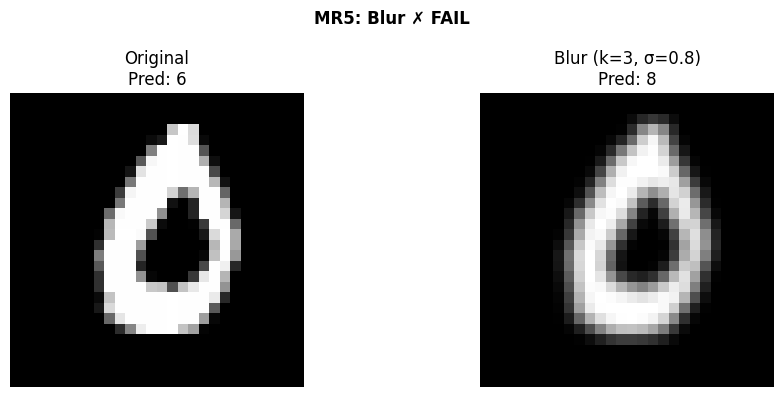

Top-1 match: False (threshold: 0.8) → FAIL


In [13]:
# MR5: Gaussian blur
blur_kernel = 3  # kernel size (must be odd, e.g., 3, 5, 7, 9...)
blur_sigma = 0.8
follow_up = gaussian_blur(source_image, kernel_size=blur_kernel, sigma=blur_sigma)
follow_up_logits = predict_logits(model, follow_up, device)[0]
follow_up_pred = torch.argmax(follow_up_logits).item()

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(source_image[0].squeeze().numpy(), cmap='gray')
axes[0].set_title(f'Original\nPred: {source_pred}')
axes[0].axis('off')

axes[1].imshow(follow_up[0].squeeze().numpy(), cmap='gray')
axes[1].set_title(f'Blur (k={blur_kernel}, σ={blur_sigma})\nPred: {follow_up_pred}')
axes[1].axis('off')

verdict = "✓ PASS" if source_pred == follow_up_pred else "✗ FAIL"
fig.suptitle(f'MR5: Blur {verdict}', fontweight='bold')
plt.tight_layout()
plt.show()

match_rate = (source_pred == follow_up_pred)
threshold = float(config["thresholds"]["blur_top1_match_rate"])
print(f"Top-1 match: {match_rate} (threshold: {threshold}) → {'PASS' if match_rate else 'FAIL'}")

## 9. Custom MR Experiment

Combine multiple transformations and test custom thresholds.

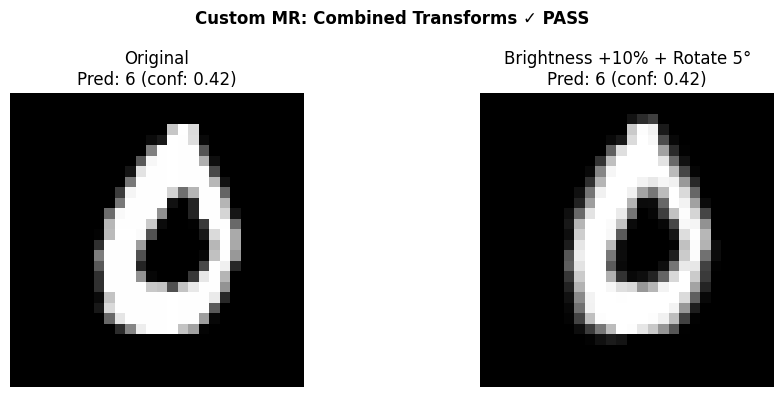

Logit diff: 0.037
Confidence delta: 0.000


In [14]:
# Combine transforms: brightness + rotation
follow_up = adjust_brightness(source_image, 1.1)  # 10% brighter
follow_up = rotate_tensor(follow_up, 5.0)  # rotate 5°
follow_up_logits = predict_logits(model, follow_up, device)[0]
follow_up_pred = torch.argmax(follow_up_logits).item()

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(source_image[0].squeeze().numpy(), cmap='gray')
axes[0].set_title(f'Original\nPred: {source_pred} (conf: {source_logits.max():.2f})')
axes[0].axis('off')

axes[1].imshow(follow_up[0].squeeze().numpy(), cmap='gray')
axes[1].set_title(f'Brightness +10% + Rotate 5°\nPred: {follow_up_pred} (conf: {follow_up_logits.max():.2f})')
axes[1].axis('off')

verdict = "✓ PASS" if source_pred == follow_up_pred else "✗ FAIL"
fig.suptitle(f'Custom MR: Combined Transforms {verdict}', fontweight='bold')
plt.tight_layout()
plt.show()

logit_diff = torch.max(torch.abs(source_logits - follow_up_logits)).item()
print(f"Logit diff: {logit_diff:.3f}")
print(f"Confidence delta: {abs(source_logits.max().item() - follow_up_logits.max().item()):.3f}")

## 10. Bug Detection Challenge

Simulate a bug: invert colors and see if MRs catch it.

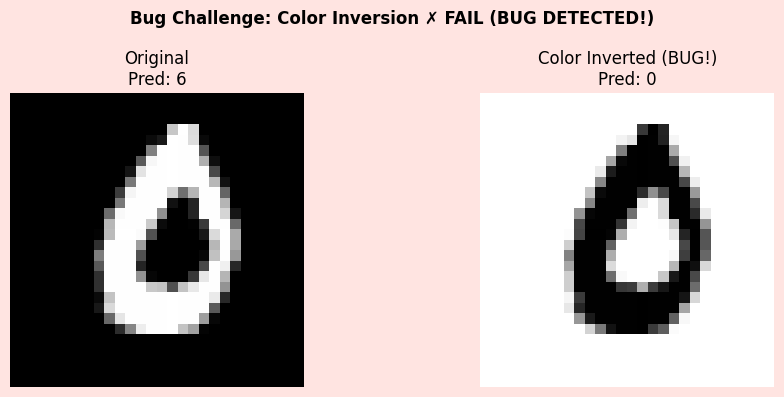


⚠️  Bug Test:
   Source pred: 6
   Inverted pred: 0
   Result: BUG DETECTED ✗


In [15]:
# Simulate a bug: invert colors
follow_up_buggy = 1.0 - source_image  # Invert colors
follow_up_buggy_logits = predict_logits(model, follow_up_buggy, device)[0]
follow_up_buggy_pred = torch.argmax(follow_up_buggy_logits).item()

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(source_image[0].squeeze().numpy(), cmap='gray')
axes[0].set_title(f'Original\nPred: {source_pred}')
axes[0].axis('off')

axes[1].imshow(follow_up_buggy[0].squeeze().numpy(), cmap='gray')
axes[1].set_title(f'Color Inverted (BUG!)\nPred: {follow_up_buggy_pred}')
axes[1].axis('off')

is_same = source_pred == follow_up_buggy_pred
verdict = "✗ FAIL (BUG DETECTED!)" if not is_same else "✓ PASS (modèle ignore inversion??)"
fig.patch.set_facecolor('mistyrose' if not is_same else 'white')
fig.suptitle(f'Bug Challenge: Color Inversion {verdict}', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\n⚠️  Bug Test:")
print(f"   Source pred: {source_pred}")
print(f"   Inverted pred: {follow_up_buggy_pred}")
print(f"   Result: {'BUG DETECTED ✗' if not is_same else 'Bug not detected (model robust!)'}") 

## 11. Summary & Export Results

In [16]:
# Run all 6 MRs on the selected image
from src.transforms import rotate_tensor

results = {}
failed_details = []

true_label = labels[image_idx].item()

def correctness_text(pred_value: int) -> str:
    return "correct" if pred_value == true_label else "wrong"

print(f"Source prediction: {source_pred} ({correctness_text(source_pred)} vs true_label={true_label})")

# MR1: Identity
follow_up = source_image.clone()
follow_up_logits = predict_logits(model, follow_up, device)[0]
pred = torch.argmax(follow_up_logits).item()
logit_diff = torch.max(torch.abs(source_logits - follow_up_logits)).item()
threshold = float(config["thresholds"]["identity_max_logit_diff"])
passed = logit_diff <= threshold
results["MR1: Identity"] = "PASS ✓" if passed else "FAIL ✗"
if not passed:
    failed_details.append(
        f"MR1 failed (consistency): max_logit_diff={logit_diff:.3e} > threshold={threshold:.3e}. "
        f"source={source_pred} ({correctness_text(source_pred)}), "
        f"follow_up={pred} ({correctness_text(pred)}), true_label={true_label}"
    )

# MR2: Double Flip
follow_up = horizontal_flip(horizontal_flip(source_image))
follow_up_logits = predict_logits(model, follow_up, device)[0]
pred = torch.argmax(follow_up_logits).item()
logit_diff = torch.max(torch.abs(source_logits - follow_up_logits)).item()
threshold = float(config["thresholds"]["double_flip_max_logit_diff"])
passed = logit_diff <= threshold
results["MR2: Double Flip"] = "PASS ✓" if passed else "FAIL ✗"
if not passed:
    failed_details.append(
        f"MR2 failed (consistency): max_logit_diff={logit_diff:.3f} > threshold={threshold:.3f}. "
        f"source={source_pred} ({correctness_text(source_pred)}), "
        f"follow_up={pred} ({correctness_text(pred)}), true_label={true_label}"
    )

# MR3: Rotate Inverse
follow_up = rotate_tensor(rotate_tensor(source_image, 12.0), -12.0)
follow_up_logits = predict_logits(model, follow_up, device)[0]
pred = torch.argmax(follow_up_logits).item()
logit_diff = torch.max(torch.abs(source_logits - follow_up_logits)).item()
threshold = float(config["thresholds"]["rotate_inverse_max_logit_diff"])
passed = logit_diff <= threshold
results["MR3: Rotate Inverse"] = "PASS ✓" if passed else "FAIL ✗"
if not passed:
    failed_details.append(
        f"MR3 failed (consistency): max_logit_diff={logit_diff:.3f} > threshold={threshold:.3f}. "
        f"source={source_pred} ({correctness_text(source_pred)}), "
        f"follow_up={pred} ({correctness_text(pred)}), true_label={true_label}"
    )

# MR4: Brightness
follow_up = adjust_brightness(source_image, 1.15)
follow_up_logits = predict_logits(model, follow_up, device)[0]
pred = torch.argmax(follow_up_logits).item()
match_rate = 1.0 if source_pred == pred else 0.0
threshold = float(config["thresholds"]["brightness_top1_match_rate"])
passed = match_rate >= threshold
results["MR4: Brightness"] = "PASS ✓" if passed else "FAIL ✗"
if not passed:
    failed_details.append(
        f"MR4 failed (consistency): top1_match_rate={match_rate:.1f} < threshold={threshold:.1f}. "
        f"source={source_pred} ({correctness_text(source_pred)}), "
        f"follow_up={pred} ({correctness_text(pred)}), true_label={true_label}"
    )

# MR5: Blur
follow_up = gaussian_blur(source_image, kernel_size=3, sigma=0.8)
follow_up_logits = predict_logits(model, follow_up, device)[0]
pred = torch.argmax(follow_up_logits).item()
match_rate = 1.0 if source_pred == pred else 0.0
threshold = float(config["thresholds"]["blur_top1_match_rate"])
passed = match_rate >= threshold
results["MR5: Blur"] = "PASS ✓" if passed else "FAIL ✗"
if not passed:
    failed_details.append(
        f"MR5 failed (consistency): top1_match_rate={match_rate:.1f} < threshold={threshold:.1f}. "
        f"source={source_pred} ({correctness_text(source_pred)}), "
        f"follow_up={pred} ({correctness_text(pred)}), true_label={true_label}"
    )

# MR6: Batch Consistency
batch_logits = predict_logits(model, source_image, device)[0]
single_logits = predict_logits(model, source_image[0:1], device)[0]
diff = torch.max(torch.abs(batch_logits - single_logits)).item()
threshold = 1e-5
passed = diff < threshold
results["MR6: Batch Consistency"] = "PASS ✓" if passed else "FAIL ✗"
if not passed:
    failed_details.append(
        f"MR6 failed (consistency): max_logit_diff={diff:.3e} >= threshold={threshold:.3e}. "
        f"source={source_pred} ({correctness_text(source_pred)}), true_label={true_label}"
    )

print("\n" + "=" * 60)
print(f"RESULTS FOR IMAGE {image_idx} (true label: {true_label})")
print("=" * 60)
for mr, verdict in results.items():
    print(f"{mr:30s} -> {verdict}")
print("=" * 60)

if failed_details:
    print("\nFAILED MR DETAILS")
    print("-" * 60)
    for detail in failed_details:
        print(f"- {detail}")
    print("\nNote: MR failure means the relation was violated (consistency issue),")
    print("not necessarily that follow-up prediction is wrong vs true label.")
else:
    print("\nNo failed MR for this image.")

Source prediction: 6 (wrong vs true_label=0)

RESULTS FOR IMAGE 10 (true label: 0)
MR1: Identity                  -> PASS ✓
MR2: Double Flip               -> PASS ✓
MR3: Rotate Inverse            -> PASS ✓
MR4: Brightness                -> FAIL ✗
MR5: Blur                      -> FAIL ✗
MR6: Batch Consistency         -> PASS ✓

FAILED MR DETAILS
------------------------------------------------------------
- MR4 failed (consistency): top1_match_rate=0.0 < threshold=0.8. source=6 (wrong), follow_up=8 (wrong), true_label=0
- MR5 failed (consistency): top1_match_rate=0.0 < threshold=0.8. source=6 (wrong), follow_up=8 (wrong), true_label=0

Note: MR failure means the relation was violated (consistency issue),
not necessarily that follow-up prediction is wrong vs true label.
